Unsupervised Machine Learning
Unsupervised Learning is a type of machine learning where the model works without labelled data. It learns patterns on its own by grouping similar data points or finding hidden structures without any human intervention.

It is used for tasks like clustering, dimensionality reduction and Association Rule Learning.
Helps identify hidden patterns in data
Useful for grouping, compression and anomaly detection
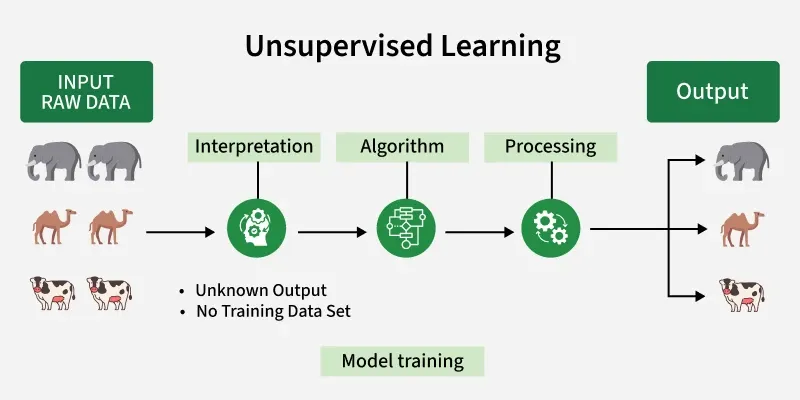
Unsupervised Learning
The image shows set of animals like elephants, camels and cows that represents raw data that the unsupervised learning algorithm will process.

The "Interpretation" stage signifies that the algorithm doesn't have predefined labels or categories for the data. It groups the data based on inherent patterns.
An algorithm represents unsupervised learning process that helps to identify patterns in the data.
The processing stage shows the algorithm working on the data.
Working of Unsupervised Learning
The working of unsupervised machine learning can be explained in these steps:

1. Collect Unlabeled Data
Gather a dataset without predefined labels or categories.
Example: Images of various animals without any tags.
2. Select an Algorithm
Choose a suitable unsupervised algorithm such as clustering like K-Means, association rule learning like Apriori or dimensionality reduction like PCA based on the goal.
3. Train the Model on Raw Data
Feed the entire unlabeled dataset to the algorithm.
The algorithm looks for similarities, relationships or hidden structures within the data.
4. Group or Transform Data
The algorithm organizes data into groups (clusters), rules or lower-dimensional forms without human input.
Example: It may group similar animals together or extract key patterns from large datasets.
5. Interpret and Use Results
Analyze the discovered groups, rules or features to gain insights or use them for further tasks like visualization, anomaly detection or as input for other models.

Clustering in Machine Learning
Clustering is an unsupervised machine learning technique used to group similar data points together without using labelled data. It helps discover hidden patterns or natural groupings in datasets by placing similar data points into the same cluster.

Discover the natural grouping or structure in unlabelled data without predefined categories.
Data points are assigned to clusters based on similarity or distance measures.
Uses Euclidean distance, cosine similarity or other metrics depending on data type and clustering method.
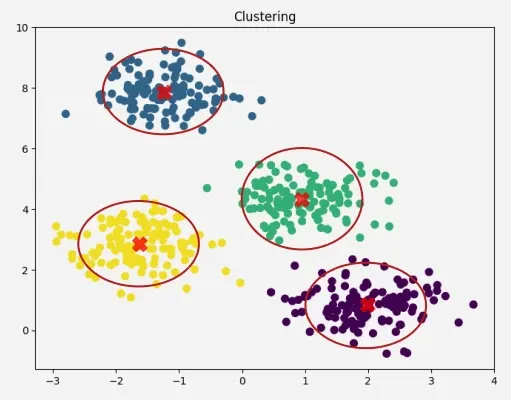
Types of Clustering
1. Hard Clustering
Hard clustering assigns each data point to exactly one cluster. A data point cannot belong to multiple clusters, making the grouping clear and easy to interpret.

Each data point belongs to only one cluster
No overlap between clusters
Simple and easy to interpret
Example

If customers are divided into two clusters, each customer belongs completely to either Cluster 1 or Cluster 2. A customer cannot belong to both clusters at the same time.

Common Uses

Market segmentation: Businesses group customers with similar buying behaviour to design targeted marketing strategies.
Customer grouping: Companies organize customers into clear categories for better service and analysis.
Document clustering: Documents with similar topics or keywords are grouped together for easier organization.
Limitation

Cannot represent overlapping groups: Hard clustering cannot handle situations where a data point may logically belong to multiple groups.

2. Soft Clustering
Soft clustering allows a data point to belong to multiple clusters with different probabilities. Instead of assigning a strict cluster, it gives a degree of membership to each cluster.

Example

A data point may belong 70% to Cluster 1 and 30% to Cluster 2, indicating that it shares characteristics with both groups.

Use Cases

Overlapping class boundaries: Useful when data points cannot be clearly separated into distinct groups.
Customer personas: Helps represent customers who share traits with multiple behavioral groups.
Medical diagnosis: Patients may show symptoms related to multiple conditions.
Benefits

Captures ambiguity: Represents uncertainty when cluster boundaries are not clear.
Models gradual transitions: Allows smooth transitions between clusters instead of strict separation.

-Agglomerative Clustering
To group similar data points into clusters based on their proximity, Agglomerative Clustering is used which is a type of hierarchical clustering. It follows a bottom-up approach, where each data point starts as its own cluster and gradually merges with others based on similarity.

The merging continues until all points form a single cluster or a set number of clusters remain.
It uses distance metrics like Euclidean or Manhattan distance to measure similarity.
The process is often visualized using a dendrogram, which shows the hierarchy of cluster formation.
Common linkage methods include single, complete, average and ward linkage.
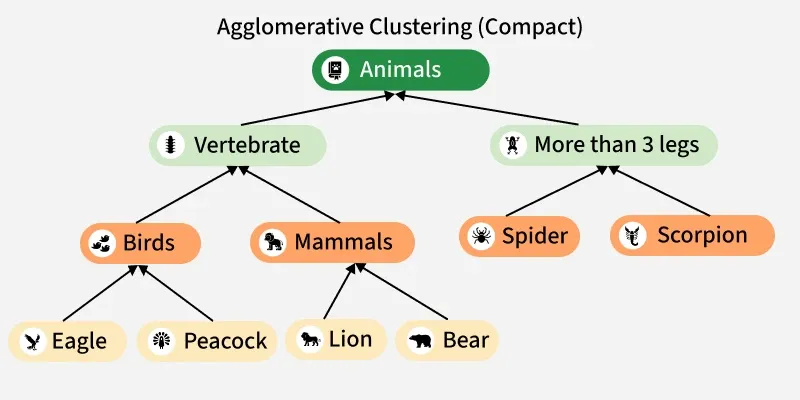
1. Start with all points separate:

Treat each data point as its own cluster like A, B, C, ...
Initially, you have n clusters for n data points.
2. Compute pairwise distances:

Calculate the distance between every pair of clusters.
Common choices include Euclidean, Manhattan or Cosine distance.
Store these values in a distance matrix.
To know more about them refer to: Measures of Distance

3. Merge the nearest clusters:

Identify the two clusters that are closest based on the chosen linkage method such as single, complete, average or Ward linkage.
Combine them into a single new cluster.
4. Update distances:

Recalculate the distances between the newly formed cluster and all remaining clusters.
Use the same linkage rule to ensure consistency.
5. Repeat the process:

Continue merging clusters and updating distances iteratively.
Stop when you reach a predefined number of clusters (k) or a distance threshold.
6. Visualize the results:

Create a dendrogram to visualize how clusters merged at each step.
Choose a suitable cut on the dendrogram to obtain the final cluster groups.

In [2]:
import matplotlib.pyplot as plt 

In [3]:
leaves = ["Eagle", "Peacock", "Lion", "Bear", "Spider", "Scorpion"]
merges = [
    ("Eagle", "Peacock", "Birds"),
    ("Lion", "Bear", "Mammals"),
    ("Spider", "Scorpion", "More than 3 legs"),
    ("Birds", "Mammals", "Vertebrate"),
    ("Vertebrate", "More than 3 legs", "Animals")
]


In [4]:
def build_tree_from_merges(leaves, merges):
    tree = {leaf: leaf for leaf in leaves}
    def replace_node(container, target, subtree):
        if isinstance(container, dict):
            if target in container:
                container[target] = subtree
                return True
            for k, v in container.items():
                if replace_node(v, target, subtree):
                    return True
        return False
    for a, b, parent in merges:
        subtree = {
            a: tree.pop(a) if a in tree else a,
            b: tree.pop(b) if b in tree else b
        }
        tree[parent] = subtree
        for top in list(tree.keys()):
            if top == parent:
                continue
            replace_node(tree[top], a, subtree)
            replace_node(tree[top], b, subtree)

    root = list(tree.keys())[0]
    return {root: tree[root]}

cluster_tree = build_tree_from_merges(leaves, merges)

In [5]:
def compute_positions(tree, x=0.0, y=0.0, dx=1.0, dy=1.0):
    positions = {}
    if isinstance(tree, dict):
        total_w = 0
        child_centers = []
        children_positions = {}
        for key, subtree in tree.items():
            sub_pos, sub_w = compute_positions(
                subtree, x + total_w * dx, y - dy, dx, dy)
            children_positions.update(sub_pos)
            xs = [px for (px, py) in sub_pos.values()]
            center_x = sum(xs) / len(xs)
            child_centers.append((key, center_x))
            total_w += sub_w
        for key, cx in child_centers:
            positions[key] = (cx, y)
        positions.update(children_positions)
        return positions, max(1, total_w)
    else:
        positions[tree] = (x, y)
        return positions, 1

positions, _ = compute_positions(cluster_tree, x=0.0, y=0.0, dx=0.9, dy=1.0)

In [6]:
def extract_edges(tree, parent=None):
    edges = []
    if isinstance(tree, dict):
        for key, subtree in tree.items():
            if parent is not None:
                edges.append((parent, key))
            edges.extend(extract_edges(subtree, key))
    return edges
edges = extract_edges(cluster_tree)

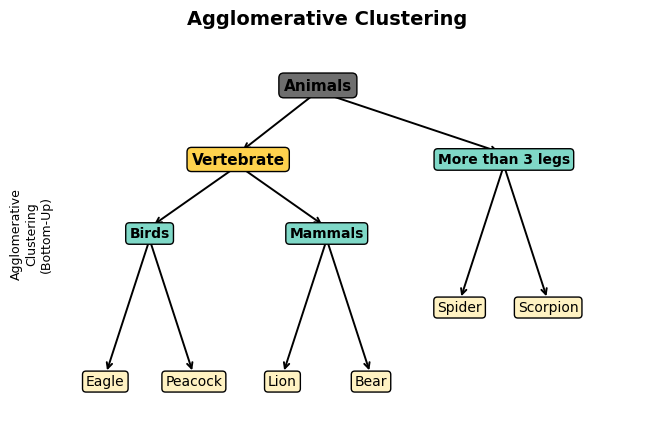

In [7]:
def plot_compact_tree(positions, edges, leaves, title="Agglomerative Clustering"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis("off")
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    xmin, xmax = min(xs) - 0.9, max(xs) + 0.9
    ymin, ymax = min(ys) - 0.6, max(ys) + 0.6
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    for parent, child in edges:
        if parent in positions and child in positions:
            x_parent, y_parent = positions[parent]
            x_child, y_child = positions[child]
            ax.annotate("",
                        xy=(x_child, y_child + 0.08), xycoords='data',
                        xytext=(x_parent, y_parent - 0.08), textcoords='data',
                        arrowprops=dict(arrowstyle="->", lw=1.4,
                                        color="black", shrinkA=4, shrinkB=4)
                        )
    for node, (x, y) in positions.items():
        if node in leaves:
            face = "#fff2c2"
            txtcol = "black"
            fontsize = 10
            pad = 0.25
        elif node == "Animals":
            face = "#6e6e6e"
            txtcol = "white"
            fontsize = 11
            pad = 0.32
        elif node == "Vertebrate":
            face = "#ffd24d"
            txtcol = "black"
            fontsize = 11
            pad = 0.30
        else:
            face = "#7fd8c7"
            txtcol = "black"
            fontsize = 10
            pad = 0.27
        ax.text(x, y, node, ha="center", va="center",
                fontsize=fontsize, weight="bold" if node not in leaves else "normal",
                bbox=dict(boxstyle="round,pad={}".format(pad),
                          facecolor=face, edgecolor="black"))
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.text(xmin + 0.15, (ymin + ymax) / 2, "Agglomerative\nClustering\n(Bottom-Up)",
            ha="center", va="center", rotation=90, fontsize=9)
    try:
        out_path = "/mnt/data/agglomerative_compact.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved compact tree to: {out_path}")
    except Exception:
        pass
    plt.show()
plot_compact_tree(positions, edges, leaves)

Divisive Clustering

Divisive Clustering is a type of hierarchical clustering that follows a top-down approach. It starts by placing all data points into one large cluster and then recursively splits that cluster into smaller ones based on differences or distances between the points. This process continues until each cluster contains only similar data points or meets a stopping condition. It is the opposite of agglomerative clustering, which builds clusters from the bottom up. It is is useful when we want to break down a broad category into smaller, meaningful groups.
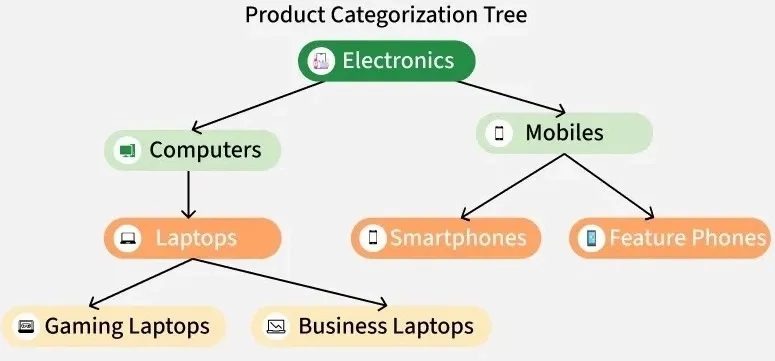
Workflow of Divisive Clustering
Start with all data points: Begin with one big group ABCDEFGH.
First split: Divide it into two groups ABC and DEFGH.
Split again: The group ABC is divided into A and BC while the group DEFGH is split into DEFG and H.
Keep dividing: We continue dividing these new groups. BC is split into B and C, DEFG is divided into DE and so on. At this stage most of the data points are now in their individual groups.
Finish: Stop when all points are separated.
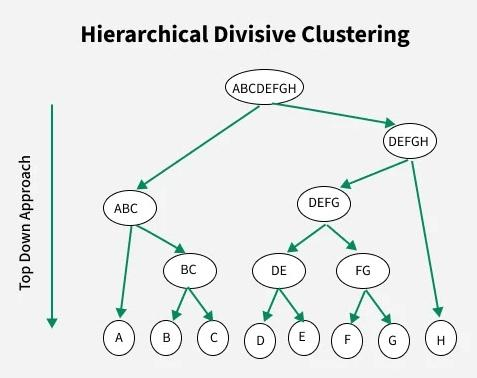


In [8]:
fruit_tree = {
    "All Fruits": {
        "Citrus": ["Orange", "Lemon"],
        "Non-Citrus": {
            "Berries": ["Strawberry", "Blueberry"],
            "Others": ["Apple", "Banana"]
        }
    }
}

In [9]:
def compute_positions(tree, x=0, y=0, dx=2):
    positions = {}
    if isinstance(tree, dict):
        all_child_positions = {}
        total_width = 0
        child_centers = []
        for key, subtree in tree.items():
            sub_pos, sub_width = compute_positions(subtree, x + total_width * dx, y - 2, dx)
            all_child_positions.update(sub_pos)
            child_center_x = sum(pos[0] for pos in sub_pos.values()) / len(sub_pos)
            child_centers.append((key, child_center_x))
            total_width += sub_width
        center_x = sum(center for _, center in child_centers) / len(child_centers)
        positions = {key: (center, y) for key, center in child_centers}
        positions.update(all_child_positions)
        return positions, total_width
    elif isinstance(tree, list):
        for i, item in enumerate(tree):
            positions[item] = (x + i * dx, y)
        return positions, len(tree)
    return {}, 0

In [10]:
def extract_edges(tree, parent=None):
    edges = []
    if isinstance(tree, dict):
        for key, subtree in tree.items():
            if parent:
                edges.append((parent, key))
            edges.extend(extract_edges(subtree, key))
    elif isinstance(tree, list):
        for item in tree:
            if parent:
                edges.append((parent, item))
    return edges

In [11]:
def plot_tree(tree):
    positions, _ = compute_positions(tree)
    edges = extract_edges(tree)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')

    for parent, child in edges:
        if parent in positions and child in positions:
            x1, y1 = positions[parent]
            x2, y2 = positions[child]
            ax.plot([x1, x2], [y1, y2], 'k-')

    for node, (x, y) in positions.items():
        if node == "All Fruits":
            color = "lightblue"
        elif node in ["Citrus", "Non-Citrus", "Berries", "Others"]:
            color = "lightgreen"
        else:
            color = "lightyellow"
        ax.text(x, y, node, ha='center', va='center',
                bbox=dict(boxstyle="round", facecolor=color, edgecolor="black"))

    plt.title("Divisive Clustering Tree: Fruit Classification", fontsize=14)
    plt.tight_layout()
    plt.show()

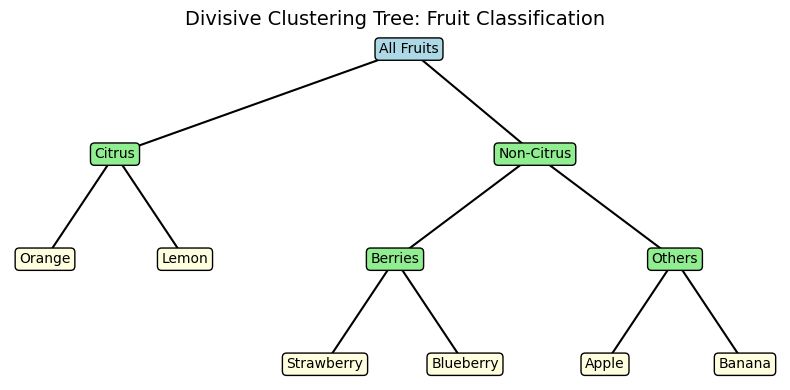

In [12]:
plot_tree(fruit_tree)

K means Clustering
K-Means Clustering groups similar data points into clusters without needing labeled data. It is used to uncover hidden patterns when the goal is to organize data based on similarity.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

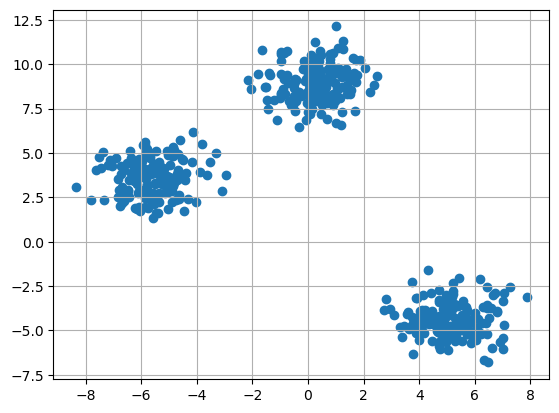

In [14]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [15]:
k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

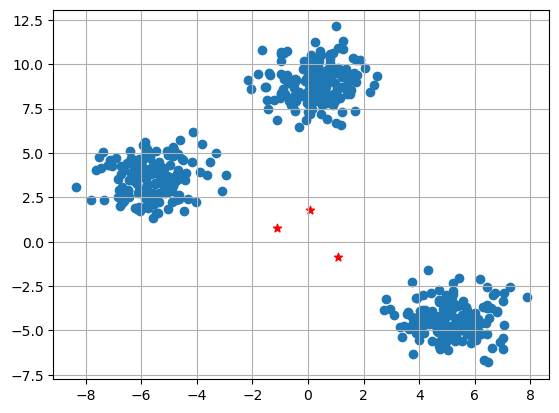

In [16]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

In [17]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []
        
        curr_x = X[idx]
        
        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center
            
            clusters[i]['points'] = []
    return clusters

In [18]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred 

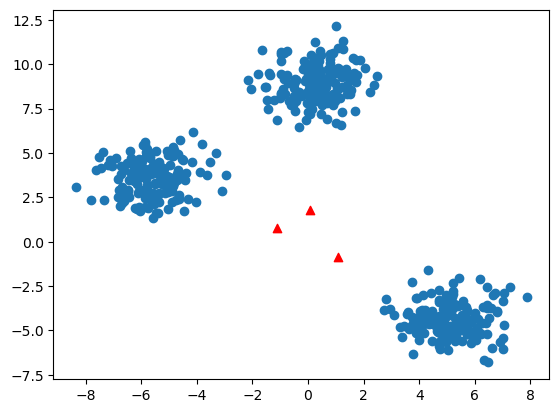

In [23]:
plt.scatter(X[:,0],X[:,1],)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

Hierarchical Clustering in Machine Learning
Hierarchical Clustering is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters
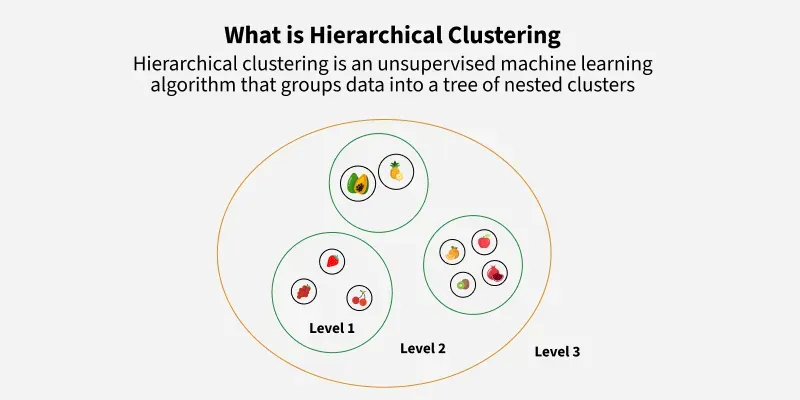
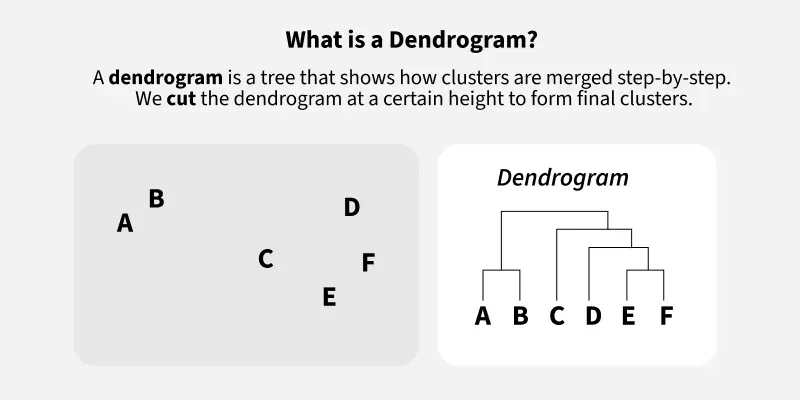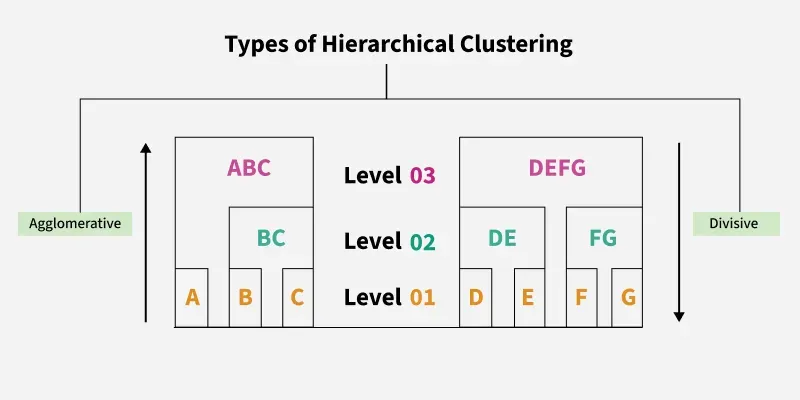

Types of Hierarchical Clustering
Now we understand the basics of hierarchical clustering. There are two main types of hierarchical clustering.

Agglomerative Clustering
Divisive clustering

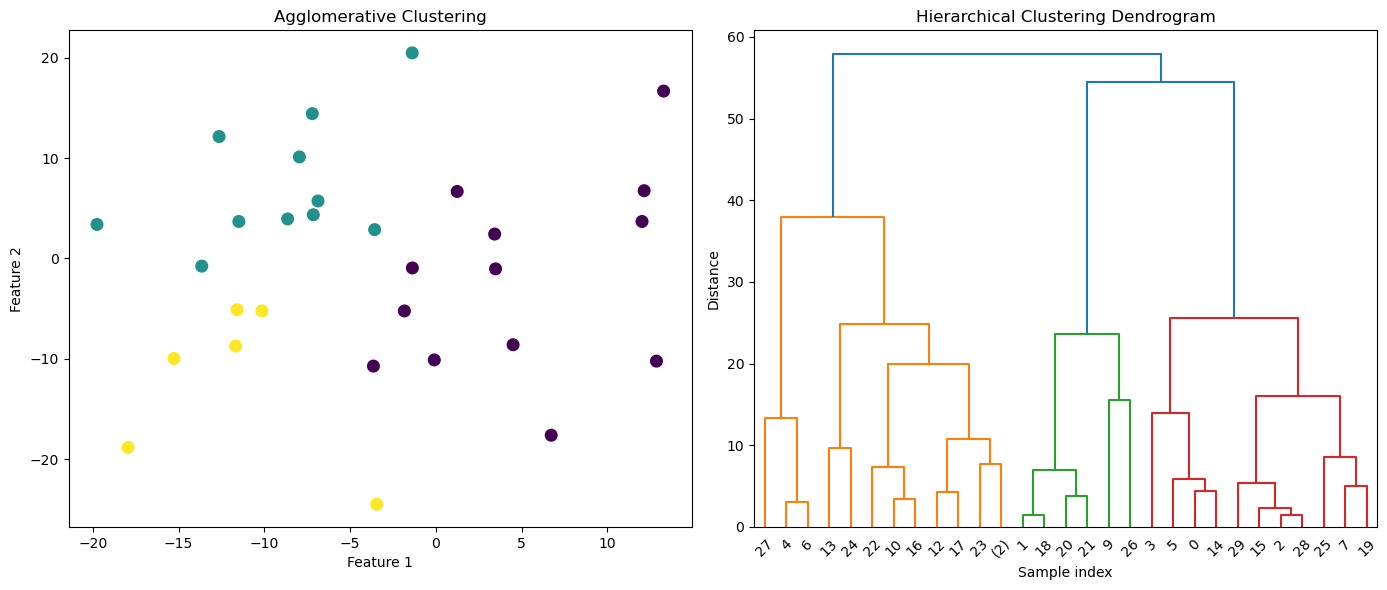

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

C:\Users\batth\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\batth\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


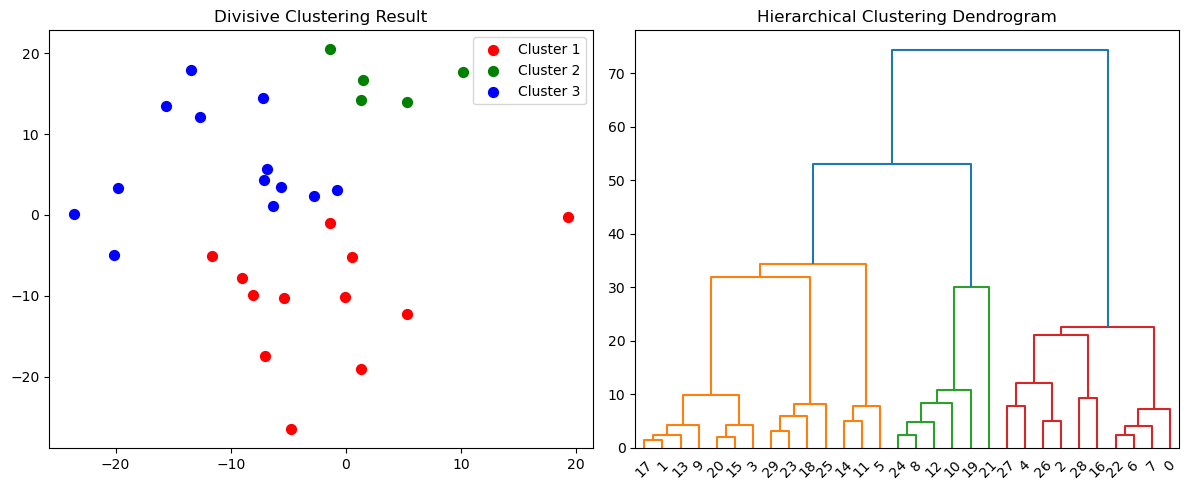

In [26]:
#Divisive hierarchy 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

X, _ = make_blobs(n_samples=30, centers=5, cluster_std=10, random_state=42)


def divisive_clustering(data, max_clusters=3):
    clusters = [data]
    while len(clusters) < max_clusters:
        cluster_to_split = max(clusters, key=lambda x: len(x))
        clusters.remove(cluster_to_split)

        kmeans = KMeans(n_clusters=2, random_state=42).fit(cluster_to_split)
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])
    return clusters


clusters = divisive_clustering(X, max_clusters=3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], s=50,
                c=colors[i], label=f'Cluster {i+1}')
plt.title('Divisive Clustering Result')
plt.legend()

linked = linkage(X, method='ward')

plt.subplot(1, 2, 2)
dendrogram(linked, orientation='top',
           distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')

plt.tight_layout()
plt.show()

DBSCAN Clustering in ML
How Does DBSCAN Work
DBSCAN works by categorizing data points into three types:

Core points which have a sufficient number of neighbors within a specified radius (eplison)
Border points which are near core points but lack enough neighbors to be core points themselves
Noise points which do not belong to any cluster.
By iteratively expanding clusters from core points and connecting density-reachable points, DBSCAN forms clusters without relying on rigid assumptions about their shape or size.

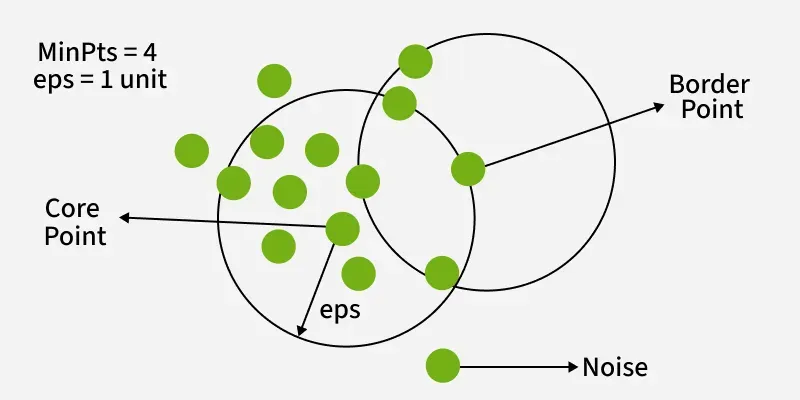)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import adjusted_rand_score

In [28]:
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.50, random_state=0)

['y', 'b', 'g', 'r']


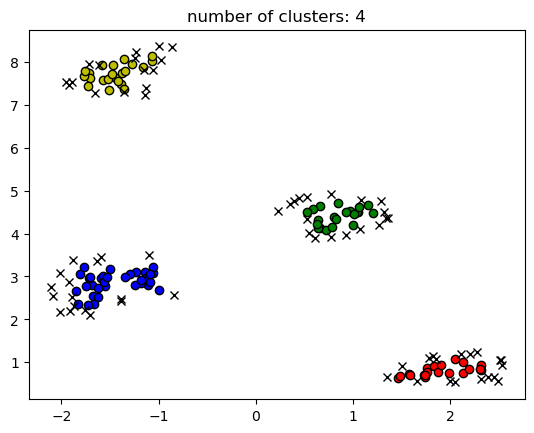

In [29]:
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
       
        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=col,
             markeredgecolor='k',
             markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

Evaluation Metrics
We will use the Silhouette score and Adjusted rand score for evaluating clustering algorithms.

Silhouette's score is in the range of -1 to 1. A score near 1 denotes the best meaning that the data point i is very compact within the cluster to which it belongs and far away from the other clusters. The worst value is -1. Values near 0 denote overlapping clusters.
Adjusted Rand Score is in the range of 0 to 1. More than 0.9 denotes excellent cluster recovery and above 0.8 is a good recovery. Less than 0.5 is considered to be poor recovery. 

In [30]:
from sklearn import metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31
